# MediaPipe Skeleton Extraction
# Ruder-Videos → Skelett auf schwarzem Hintergrund → gespeicherte Frames für CNN

## Schritt 0: Installation 

In [20]:
!pip install mediapipe opencv-python

In [21]:
import cv2
import numpy as np
import urllib.request
import ssl
from pathlib import Path
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import pandas as pd

# SSL-Fix für macOS
ssl_context = ssl._create_unverified_context()

POSE_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),(9,10),
    (11,12),(11,13),(13,15),(15,17),(15,19),(15,21),(17,19),
    (12,14),(14,16),(16,18),(16,20),(16,22),(18,20),
    (11,23),(12,24),(23,24),
    (23,25),(25,27),(27,29),(27,31),(29,31),
    (24,26),(26,28),(28,30),(28,32),(30,32),
]

MODEL_PATH = "pose_landmarker.task"
if not Path(MODEL_PATH).exists():
    print("Lade Modell herunter (~7 MB)...")
    url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task"
    with urllib.request.urlopen(url, context=ssl_context) as response:
        with open(MODEL_PATH, "wb") as f:
            f.write(response.read())
    print("Modell gespeichert.")
else:
    print("Modell bereits vorhanden.")

print("Libraries loaded.")

Modell bereits vorhanden.
Libraries loaded.


## Schritt 1: Pfade 

In [ ]:
# ── INPUT ──────────────────────────────────────────────────────────────
VIDEO_PATH = Path("/Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/Data/OG_Videos/sim-GOOD-slow.mov")

# ── OUTPUT ─────────────────────────────────────────────────────────────
# Data directory (derived from the video path)
DATA_DIR = VIDEO_PATH.parent.parent  # .../1_DatasetCharacteristics/Data
FRAMES_BASE = DATA_DIR / "skeleton_frames"
OUTPUT_DIR = FRAMES_BASE / (VIDEO_PATH.stem + "-skeleton")
VIDEO_DIR = DATA_DIR / "skeleton_videos"

# ── EDA output (zusätzlich) ─────────────────────────────────────────────
# Aggregierte EDA-Ergebnisse (Stroke times + Plots) unter: '.../1_DatasetCharacteristics/EDA_data/<video_stem>-skeleton'
EDA_BASE = DATA_DIR.parent / "EDA_data/normalized"
EDA_OUTPUT_DIR = EDA_BASE / (VIDEO_PATH.stem + "-skeleton")

# create directories
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
VIDEO_DIR.mkdir(parents=True, exist_ok=True)
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FRAME_SIZE  = (256, 256)   # Auflösung der gespeicherten Skelett-Frames
SAVE_VIDEO  = True          # True → zusätzlich ein zusammengesetztes .mp4 speichern

print(f"Video:  {VIDEO_PATH}")
print(f"Frames output: {OUTPUT_DIR}")
print(f"Video output: {VIDEO_DIR}")
print(f"EDA output: {EDA_OUTPUT_DIR}")

Video:  /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/Data/OG_Videos/sim-GOOD-slow.mov
Frames output: /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/Data/skeleton_frames/sim-GOOD-slow-skeleton
Video output: /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/Data/skeleton_videos
EDA output: /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/EDA_data/sim-GOOD-slow-skeleton


## Schritt 2: Skelett-Extraktion ausführen

In [23]:
cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"FPS: {fps:.1f}  |  Frames gesamt: {total_frames}")

video_writer = None
out_video_path = None
if SAVE_VIDEO:
    # Save the assembled video in the dedicated VIDEO_DIR
    out_video_path = str(VIDEO_DIR / (VIDEO_PATH.stem + "_skeleton.mp4"))
    video_writer = cv2.VideoWriter(
        out_video_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, FRAME_SIZE
    )

def draw_skeleton(canvas, landmarks, frame_shape):
    h, w = frame_shape[:2]
    points = [(int(lm.x * w), int(lm.y * h)) for lm in landmarks]
    for a, b in POSE_CONNECTIONS:
        cv2.line(canvas, points[a], points[b], (180, 180, 180), 2)
    for pt in points:
        cv2.circle(canvas, pt, 3, (255, 255, 255), -1)

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
)

label = [1, 0]   # GOOD: [1,0] | BAD: [0,1]
all_rows = []
saved = 0
no_pose = 0

with vision.PoseLandmarker.create_from_options(options) as landmarker:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        timestamp_ms = int(saved * 1000 / fps)
        results = landmarker.detect_for_video(mp_image, timestamp_ms)

        canvas = np.zeros((frame.shape[0], frame.shape[1], 3), dtype=np.uint8)

        if results.pose_landmarks:
            draw_skeleton(canvas, results.pose_landmarks[0], frame.shape)
            # Koordinaten extrahieren und speichern
            row = []
            for point in results.pose_landmarks[0]:
                row.extend([point.x, point.y, point.z])
            row.extend(label)   # z.B. "GOOD" oder "BAD"
            all_rows.append(row)
        else:
            no_pose += 1

        canvas = cv2.resize(canvas, FRAME_SIZE)
        cv2.imwrite(str(OUTPUT_DIR / f"frame_{saved:05d}.png"), canvas)

        if video_writer:
            video_writer.write(canvas)

        saved += 1

cap.release()
if video_writer:
    video_writer.release()

print(f"\nFertig! {saved} Frames gespeichert → {OUTPUT_DIR}")
print(f"Frames ohne erkannte Pose: {no_pose}")
if SAVE_VIDEO:
    print(f"Video gespeichert → {out_video_path}")

FPS: 30.0  |  Frames gesamt: 7419


I0000 00:00:1782243780.413468 4174775 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1782243780.453596 4174779 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782243780.474811 4174779 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



Fertig! 7419 Frames gespeichert → /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/Data/skeleton_frames/sim-GOOD-slow-skeleton
Frames ohne erkannte Pose: 0
Video gespeichert → /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/Data/skeleton_videos/sim-GOOD-slow_skeleton.mp4


E0000 00:00:1782243858.865614 4174776 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-06-23T21:59:00.457465+02:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


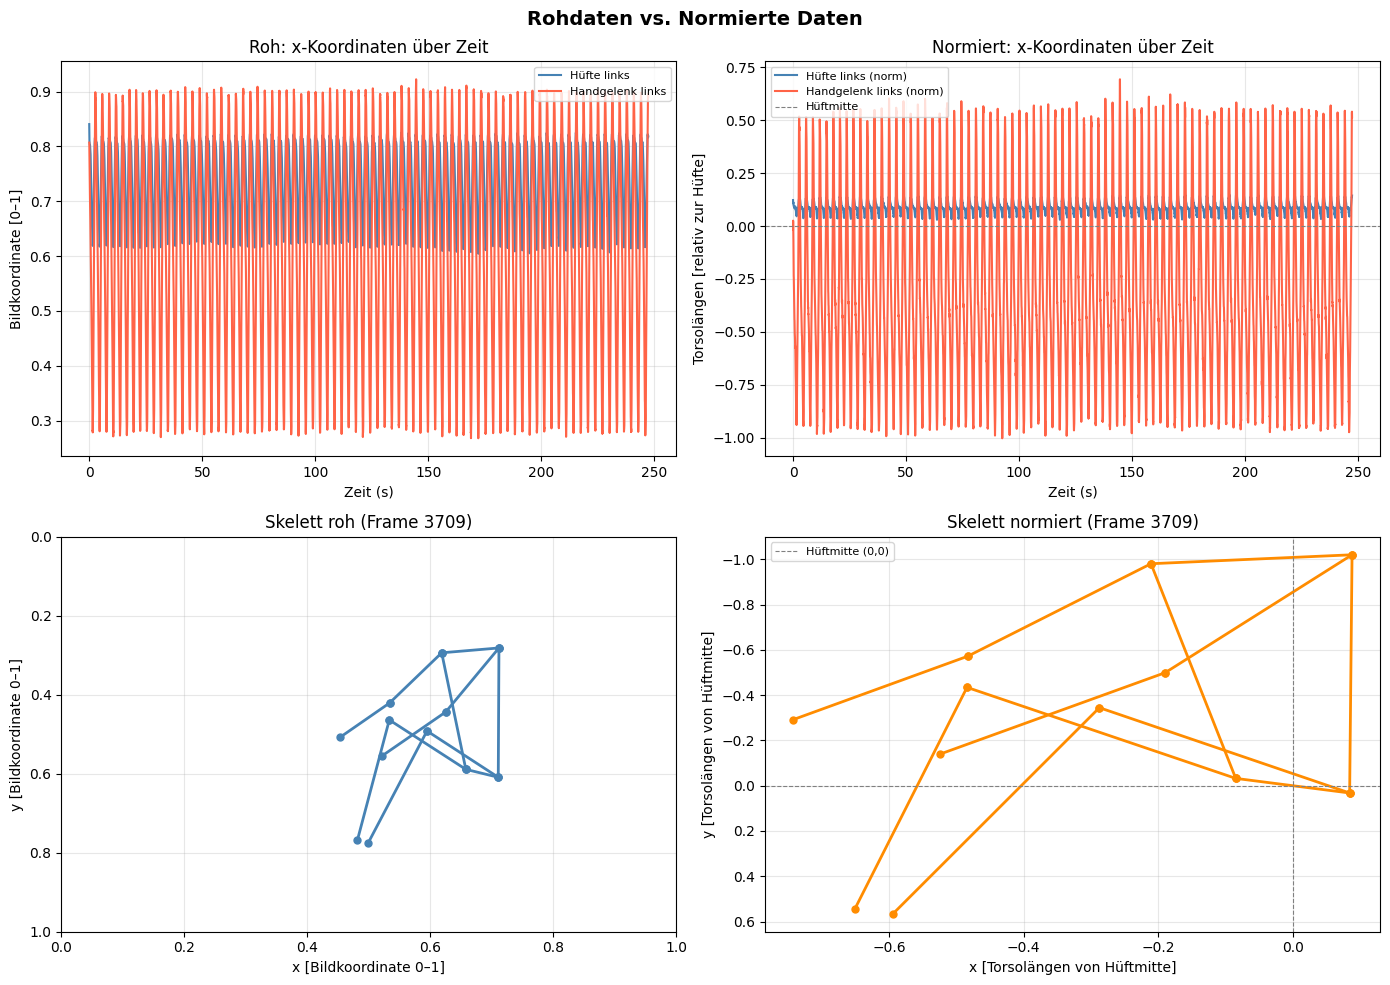

In [25]:
# Normierung der Daten: relative Koordinaten (x,y) der Landmarks zur Hüftmitte, skaliert auf Torsolänge

# Referenzpunkt: Hüftmitte
hip_cx = (df["left_hip_x"] + df["right_hip_x"]) / 2
hip_cy = (df["left_hip_y"] + df["right_hip_y"]) / 2

# Referenzlänge: Torso (Hüfte → Schulter)
shoulder_cy = (df["left_shoulder_y"] + df["right_shoulder_y"]) / 2
torso_length = (hip_cy - shoulder_cy).abs()  # in Bildkoordinaten

# Alle x/y-Spalten sammeln
landmark_cols = [c for c in df.columns if c.endswith("_x") or c.endswith("_y")]

# Alle Landmarks normieren: relativ zur Hüftmitte, skaliert auf Torsolänge
for col in landmark_cols:
    if col.endswith("_x"):
        df[col + "_norm"] = (df[col] - hip_cx) / torso_length
    elif col.endswith("_y"):
        df[col + "_norm"] = (df[col] - hip_cy) / torso_length

# ---------------------------------- Vorbereitung für Visualisierung: Vorher vs. Nachher
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(len(df)) / fps

# Skelett-Verbindungen (MediaPipe)
connections = [
    ("left_shoulder",  "right_shoulder"),
    ("left_shoulder",  "left_hip"),
    ("right_shoulder", "right_hip"),
    ("left_hip",       "right_hip"),
    ("left_hip",       "left_knee"),
    ("right_hip",      "right_knee"),
    ("left_knee",      "left_ankle"),
    ("right_knee",     "right_ankle"),
    ("left_shoulder",  "left_elbow"),
    ("right_shoulder", "right_elbow"),
    ("left_elbow",     "left_wrist"),
    ("right_elbow",    "right_wrist"),
]

def draw_skeleton(ax, row, x_suf, y_suf, color="steelblue"):
    for j1, j2 in connections:
        x = [row.get(f"{j1}{x_suf}", np.nan), row.get(f"{j2}{x_suf}", np.nan)]
        y = [row.get(f"{j1}{y_suf}", np.nan), row.get(f"{j2}{y_suf}", np.nan)]
        ax.plot(x, y, "o-", color=color, linewidth=2, markersize=5)

frame_idx = len(df) // 2
row = df.iloc[frame_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Rohdaten vs. Normierte Daten", fontsize=14, fontweight="bold")

# ── Oben links: Rohsignal Zeitreihe ──────────────────────────────────
ax = axes[0, 0]
ax.plot(time, df["left_hip_x"],   color="steelblue", linewidth=1.5, label="Hüfte links")
ax.plot(time, df["left_wrist_x"], color="tomato",    linewidth=1.5, label="Handgelenk links")
ax.set_title("Roh: x-Koordinaten über Zeit")
ax.set_xlabel("Zeit (s)")
ax.set_ylabel("Bildkoordinate [0–1]")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Oben rechts: Normiertes Signal Zeitreihe ─────────────────────────
ax = axes[0, 1]
ax.plot(time, df["left_hip_x_norm"],   color="steelblue", linewidth=1.5, label="Hüfte links (norm)")
ax.plot(time, df["left_wrist_x_norm"], color="tomato",    linewidth=1.5, label="Handgelenk links (norm)")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", label="Hüftmitte")
ax.set_title("Normiert: x-Koordinaten über Zeit")
ax.set_xlabel("Zeit (s)")
ax.set_ylabel("Torsolängen [relativ zur Hüfte]")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Unten links: Skelett roh ──────────────────────────────────────────
ax = axes[1, 0]
draw_skeleton(ax, row, "_x", "_y")
ax.set_title(f"Skelett roh (Frame {frame_idx})")
ax.set_xlabel("x [Bildkoordinate 0–1]")
ax.set_ylabel("y [Bildkoordinate 0–1]")
ax.set_xlim(0, 1)
ax.set_ylim(1, 0)  # y invertiert: Bildkoordinaten gehen von oben nach unten
ax.grid(alpha=0.3)

# ── Unten rechts: Skelett normiert ───────────────────────────────────
ax = axes[1, 1]
draw_skeleton(ax, row, "_x_norm", "_y_norm", color="darkorange")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", label="Hüftmitte (0,0)")
ax.set_title(f"Skelett normiert (Frame {frame_idx})")
ax.set_xlabel("x [Torsolängen von Hüftmitte]")
ax.set_ylabel("y [Torsolängen von Hüftmitte]")
ax.invert_yaxis()
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Landmark-Daten in CSV speichern
LANDMARK_NAMES = [
    "nose", "left_eye_inner", "left_eye", "left_eye_outer",
    "right_eye_inner", "right_eye", "right_eye_outer",
    "left_ear", "right_ear", "mouth_left", "mouth_right",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_pinky", "right_pinky",
    "left_index", "right_index", "left_thumb", "right_thumb",
    "left_hip", "right_hip", "left_knee", "right_knee",
    "left_ankle", "right_ankle", "left_heel", "right_heel",
    "left_foot_index", "right_foot_index",
]

cols = [f"{name}_{ax}" for name, ax in zip(
    [n for n in LANDMARK_NAMES for _ in range(3)],
    ["x", "y", "z"] * 33
)] + ["Good Stroke", "Bad Stroke"]


df = pd.DataFrame(all_rows, columns=cols)

csv_path = DATA_DIR.parent / "landmarks/normalized" / (VIDEO_PATH.stem + "-landmarks.csv")
csv_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(csv_path, index=False)
print(f"Landmarks gespeichert → {csv_path}")

Landmarks gespeichert → /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/landmarks/sim-GOOD-slow-landmarks.csv


In [27]:
# !! Nur ausführen wenn ALLE Videos verarbeitet wurden !!
# landmarks_dir = DATA_DIR.parent / "landmarks"
# csvs = sorted(landmarks_dir.glob("*-landmarks.csv"))
# print(f"Gefundene CSVs: {[f.name for f in csvs]}")

# df_all = pd.concat([pd.read_csv(f) for f in csvs])
# df_all.to_csv(landmarks_dir / "landmarks_all.csv", index=False)
# print(f"Gesamt-CSV: {df_all.shape[0]} Zeilen")


## Schritt 3: Vorschau — ersten Frame anzeigen

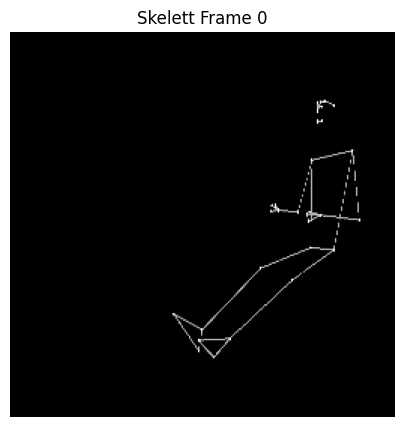

In [28]:
import matplotlib.pyplot as plt

preview = cv2.imread(str(OUTPUT_DIR / "frame_00000.png"))
preview = cv2.cvtColor(preview, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(preview)
plt.title("Skelett Frame 0")
plt.axis("off")
plt.show()

## Schritt 4: Zyklusdetektion — Schläge zählen

In [29]:
!pip install scipy

In [30]:
# Hüft-Trajektorie aus dem Originalvideo extrahieren (nur Koordinaten, keine Bilder)
cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
)

hip_x = []

with vision.PoseLandmarker.create_from_options(options) as landmarker:
    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        results = landmarker.detect_for_video(mp_image, int(frame_idx * 1000 / fps))

        if results.pose_landmarks:
            lm = results.pose_landmarks[0]
            # Durchschnitt linke (23) + rechte (24) Hüfte
            hip_x.append((lm[23].x + lm[24].x) / 2)
        else:
            hip_x.append(hip_x[-1] if hip_x else 0.5)

        frame_idx += 1

cap.release()
hip_x = np.array(hip_x)
print(f"Trajektorie extrahiert: {len(hip_x)} Frames bei {fps:.0f} FPS")

I0000 00:00:1782243941.261065 4176727 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1782243941.319167 4176729 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782243941.333945 4176729 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Trajektorie extrahiert: 7419 Frames bei 30 FPS


E0000 00:00:1782244014.833215 4176728 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-06-23T22:01:41.399172+02:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180


1. hip_x  →  glätten  →  norm01

2. wrist_x → glätten  →  norm01

    → mitteln → combined → Peaks = Endzug; Valleys = Auslage


In [ ]:
from scipy.signal import find_peaks, savgol_filter

# Mittelwert der Hüft- und Handgelenk-x-Koordinaten
hip_x = (df["left_hip_x"].values + df["right_hip_x"].values) / 2
wrist_x = (df["left_wrist_x"].values + df["right_wrist_x"].values) / 2

# Glätten
window = max(int(fps * 0.5) | 1, 5)
hip_smoothed   = savgol_filter(hip_x,   window_length=window, polyorder=3)
wrist_smoothed = savgol_filter(wrist_x, window_length=window, polyorder=3)

# Normieren auf [0, 1]:
def norm01(x):
    return (x - x.min()) / (x.max() - x.min())

hip_norm   = norm01(hip_smoothed)
wrist_norm = norm01(wrist_smoothed)
combined   = (hip_norm + wrist_norm) / 2   # gleichgewichtet

min_dist = int(fps * 0.8)

peaks,   _ = find_peaks( combined, distance=min_dist, prominence=0.01)
valleys, _ = find_peaks(-combined, distance=min_dist, prominence=0.01)

n_strokes  = len(peaks)
duration_s = len(hip_x) / fps
rate       = n_strokes / duration_s * 60

print(f"Erkannte Schläge:  {n_strokes}")
print(f"Videodauer:        {duration_s:.1f} s")
print(f"Schlagrate:        {rate:.1f} Schläge/Minute")


Erkannte Schläge:  77
Videodauer:        247.4 s
Schlagrate:        18.7 Schläge/Minute


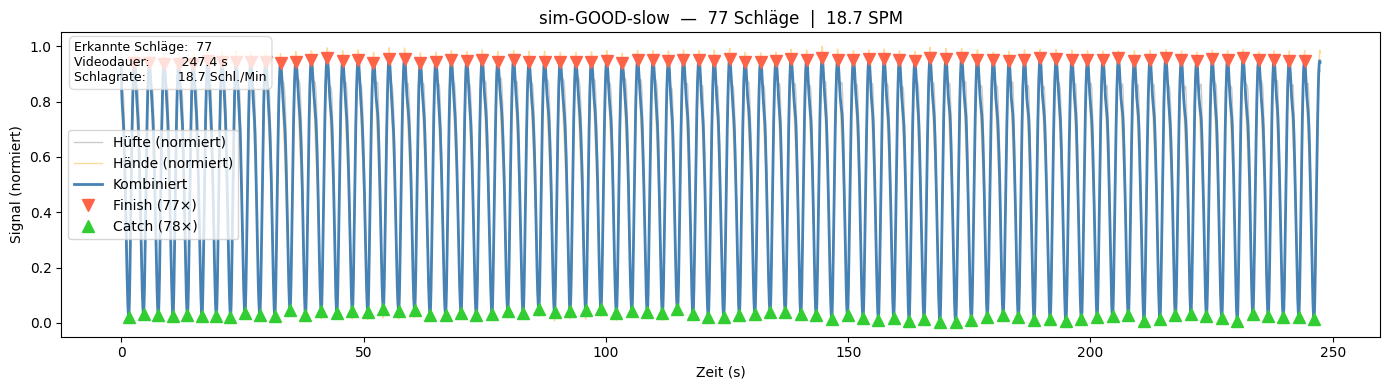

Stroke times saved → /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/EDA_data/sim-GOOD-slow-skeleton/stroke_times.txt
Plot saved → /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/EDA_data/sim-GOOD-slow-skeleton/stroke_plot.png


In [32]:
import matplotlib.pyplot as plt

time = np.arange(len(hip_x)) / fps

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time, hip_norm,   color="gray",      alpha=0.4, linewidth=1, label="Hüfte (normiert)")
ax.plot(time, wrist_norm, color="orange",    alpha=0.4, linewidth=1, label="Hände (normiert)")
ax.plot(time, combined,   color="steelblue", linewidth=2,            label="Kombiniert")
ax.plot(time[peaks],   combined[peaks],   "v", color="tomato",    markersize=8, label=f"Finish ({n_strokes}×)")
ax.plot(time[valleys], combined[valleys], "^", color="limegreen", markersize=8, label=f"Catch ({len(valleys)}×)")
ax.set_xlabel("Zeit (s)")
ax.set_ylabel("Signal (normiert)")
ax.set_title(f"{VIDEO_PATH.stem}  —  {n_strokes} Schläge  |  {rate:.1f} SPM")
ax.legend()

stats_text = (
    f"Erkannte Schläge:  {n_strokes}\n"
    f"Videodauer:        {duration_s:.1f} s\n"
    f"Schlagrate:        {rate:.1f} Schl./Min"
)
ax.text(
    0.01, 0.97, stats_text,
    transform=ax.transAxes,
    fontsize=9, verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8, edgecolor="lightgray"),
)

plt.tight_layout()
plt.show()

output_txt = EDA_OUTPUT_DIR / "stroke_times.txt"
with open(output_txt, "w") as f:
    f.write("Finish-Zeiten (s):\n")
    f.write(", ".join(f"{time[p]:.2f}" for p in peaks) + "\n\n")
    f.write("Catch-Zeiten (s):\n")
    f.write(", ".join(f"{time[v]:.2f}" for v in valleys) + "\n")
print(f"Stroke times saved → {output_txt}")

output_png = EDA_OUTPUT_DIR / "stroke_plot.png"
fig.savefig(output_png)
print(f"Plot saved → {output_png}")

In [33]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, savgol_filter

# Hüft-x und Handgelenk-x (Mitte links/rechts)
hip_x_raw   = (df["left_hip_x"].values   + df["right_hip_x"].values)   / 2
wrist_x_raw = (df["left_wrist_x"].values + df["right_wrist_x"].values) / 2

# Glätten
window = max(int(fps * 0.5) | 1, 5)
hip_smooth   = savgol_filter(hip_x_raw,   window_length=window, polyorder=3)
wrist_smooth = savgol_filter(wrist_x_raw, window_length=window, polyorder=3)

# Normieren und kombinieren
def norm01(x):
    return (x - x.min()) / (x.max() - x.min())

combined = (norm01(hip_smooth) + norm01(wrist_smooth)) / 2

min_dist = int(fps * 0.8)

# Endzug = Peaks (Hüfte hinten + Hände angezogen)
# Auslage = Täler (Hüfte vorne + Arme ausgestreckt)
endzug_frames,  _ = find_peaks( combined, distance=min_dist, prominence=0.01)
auslage_frames, _ = find_peaks(-combined, distance=min_dist, prominence=0.01)

# ── Schläge segmentieren ─────────────────────────────────────────────
strokes = []

for i in range(len(endzug_frames) - 1):
    ez_start = endzug_frames[i]
    ez_end   = endzug_frames[i + 1]

    candidates = auslage_frames[(auslage_frames > ez_start) & (auslage_frames < ez_end)]
    if len(candidates) == 0:
        continue

    # Kandidat mit niedrigstem kombinierten Score = maximale Auslage (Hüfte + Hände)
    catch_frame = candidates[np.argmin(combined[candidates])]

    strokes.append({
        "schlag_nr":       i + 1,
        "endzug_start":    ez_start,
        "auslage":         catch_frame,
        "endzug_end":      ez_end,
        "vorrolle_frames": catch_frame - ez_start,
        "antrieb_frames":  ez_end - catch_frame,
        "dauer_s":         (ez_end - ez_start) / fps,
    })

df_strokes = pd.DataFrame(strokes)
print(df_strokes[["schlag_nr","endzug_start","auslage","endzug_end","vorrolle_frames","antrieb_frames","dauer_s"]])

# ── Phase-Labels für jeden Frame ──────────────────────────────────────
phase = np.zeros(len(hip_smooth), dtype=int)
for s in strokes:
    phase[s["endzug_start"]:s["auslage"]] = 1  # Vorrolle
    phase[s["auslage"]:s["endzug_end"]]   = 2  # Antrieb

df["phase"] = phase


    schlag_nr  endzug_start  auslage  endzug_end  vorrolle_frames  \
0           1            81      138         173               57   
1           2           173      229         265               56   
2           3           265      320         356               55   
3           4           356      410         445               54   
4           5           445      499         535               54   
..        ...           ...      ...         ...              ...   
71         72          6846     6905        6942               59   
72         73          6942     7002        7038               60   
73         74          7038     7097        7133               59   
74         75          7133     7190        7227               57   
75         76          7227     7286        7322               59   

    antrieb_frames   dauer_s  
0               35  3.068072  
1               36  3.068072  
2               36  3.034723  
3               35  2.968026  
4               

In [34]:
# from scipy.signal import find_peaks, savgol_filter

# # Signal glätten (Fenstergröße = ~0.5 Sekunden)
# window = max(int(fps * 0.5) | 1, 5)  # ungerade Zahl
# smoothed = savgol_filter(hip_x, window_length=window, polyorder=3)

# # Mindestabstand zwischen Peaks = 0.8 Sekunden (entspricht max ~75 Schläge/Min)
# min_dist = int(fps * 0.8)

# peaks,   _ = find_peaks( smoothed, distance=min_dist, prominence=0.01)
# valleys, _ = find_peaks(-smoothed, distance=min_dist, prominence=0.01)

# # Schlaganzahl = Anzahl Peaks (Finish-Position) oder Täler (Catch-Position)
# n_strokes   = len(peaks)
# duration_s  = len(hip_x) / fps
# rate        = n_strokes / duration_s * 60

# print(f"Erkannte Schläge:  {n_strokes}")
# print(f"Videodauer:        {duration_s:.1f} s")
# print(f"Schlagrate:        {rate:.1f} Schläge/Minute")

# # ── Plot ──────────────────────────────────────────────────────────────
# import matplotlib.pyplot as plt

# time = np.arange(len(hip_x)) / fps

# fig, ax = plt.subplots(figsize=(14, 4))
# ax.plot(time, hip_x,   color="gray",  alpha=0.4, linewidth=1, label="Rohsignal")
# ax.plot(time, smoothed, color="steelblue", linewidth=2, label="Geglättet")
# ax.plot(time[peaks],   smoothed[peaks],   "v", color="tomato",    markersize=8, label=f"Finish ({n_strokes}×)")
# ax.plot(time[valleys], smoothed[valleys], "^", color="limegreen",  markersize=8, label=f"Catch ({len(valleys)}×)")
# ax.set_xlabel("Zeit (s)")
# ax.set_ylabel("Hüft-x (normiert)")
# ax.set_title(f"{VIDEO_PATH.stem}  —  {n_strokes} Schläge  |  {rate:.1f} SPM")
# ax.legend()

# stats_text = (
#     f"Erkannte Schläge:  {n_strokes}\n"
#     f"Videodauer:        {duration_s:.1f} s\n"
#     f"Schlagrate:        {rate:.1f} Schl./Min"
# )
# ax.text(
#     0.01, 0.97, stats_text,
#     transform=ax.transAxes,
#     fontsize=9, verticalalignment="top",
#     bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8, edgecolor="lightgray"),
# )

# plt.tight_layout()
# plt.show()

# # Speichern der Schlagzeiten in einer Textdatei im EDA_OUTPUT_DIR (jeweils Finish- und Catch-Zeiten) & speichern des Plots als .png
# output_txt = EDA_OUTPUT_DIR / "stroke_times.txt"
# with open(output_txt, "w") as f:
#     f.write("Finish-Zeiten (s):\n")
#     f.write(", ".join(f"{time[p]:.2f}" for p in peaks) + "\n\n")
#     f.write("Catch-Zeiten (s):\n")
#     f.write(", ".join(f"{time[v]:.2f}" for v in valleys) + "\n")
# print(f"Stroke times saved → {output_txt}")

# # Speichern des Plots als .png im EDA_OUTPUT_DIR
# output_png = EDA_OUTPUT_DIR / "stroke_plot.png"
# fig.savefig(output_png)
# print(f"Plot saved → {output_png}")

In [35]:
# import numpy as np
# import pandas as pd
# from scipy.signal import find_peaks, savgol_filter

# # ── Hilfssignale aus Landmarks laden ──────────────────────────────────
# # Voraussetzung: df (DataFrame mit allen Landmarks, wie in Schritt 2 erzeugt)
# # Alternativ: df = pd.read_csv(csv_path)

# # Hüft-x (Mitte links/rechts)
# hip_x_raw = (df["left_hip_x"].values + df["right_hip_x"].values) / 2

# # Handgelenk-x (für Auslage-Bestätigung: Arme maximal ausgestreckt = wrist_x minimal)
# wrist_x_raw = (df["left_wrist_x"].values + df["right_wrist_x"].values) / 2

# # ── Glätten ──────────────────────────────────────────────────────────
# window = max(int(fps * 0.5) | 1, 5)
# hip_smooth   = savgol_filter(hip_x_raw,   window_length=window, polyorder=3)
# wrist_smooth = savgol_filter(wrist_x_raw, window_length=window, polyorder=3)

# min_dist = int(fps * 0.8)  # mind. 0.8s zwischen Schlägen

# # Endzug = Peaks, Auslage = Täler
# endzug_frames,  _ = find_peaks( hip_smooth, distance=min_dist, prominence=0.01)
# auslage_frames, _ = find_peaks(-hip_smooth, distance=min_dist, prominence=0.01)

# # ── Schläge segmentieren ─────────────────────────────────────────────
# strokes = []

# for i in range(len(endzug_frames) - 1):
#     ez_start = endzug_frames[i]
#     ez_end   = endzug_frames[i + 1]

#     # Auslage zwischen den beiden Endzügen finden
#     candidates = auslage_frames[(auslage_frames > ez_start) & (auslage_frames < ez_end)]
#     if len(candidates) == 0:
#         continue  # kein Taler gefunden → Schlag überspringen

#     # Nimm den Taler mit niedrigstem hip_x (= maximale Vorrollung)
#     catch_frame = candidates[np.argmin(hip_smooth[candidates])]

#     strokes.append({
#         "schlag_nr":    i + 1,
#         "endzug_start": ez_start,           # Hände angezogen, Beine durch
#         "auslage":      catch_frame,         # Hüfte max. vorne, Arme ausgestreckt
#         "endzug_end":   ez_end,             # nächster Endzug = Ende des Schlags
#         "vorrolle_frames": catch_frame - ez_start,
#         "antrieb_frames":  ez_end - catch_frame,
#         "dauer_s":      (ez_end - ez_start) / fps,
#     })

# df_strokes = pd.DataFrame(strokes)
# print(df_strokes[["schlag_nr","endzug_start","auslage","endzug_end","vorrolle_frames","antrieb_frames","dauer_s"]])

# # ── Phase-Labels für jeden Frame ──────────────────────────────────────
# # 0 = unbekannt, 1 = Vorrolle (Endzug→Auslage), 2 = Antrieb (Auslage→Endzug)
# phase = np.zeros(len(hip_smooth), dtype=int)
# for s in strokes:
#     phase[s["endzug_start"]:s["auslage"]]  = 1  # Vorrolle
#     phase[s["auslage"]:s["endzug_end"]]    = 2  # Antrieb

# df["phase"] = phase  # zum bestehenden Landmark-DataFrame hinzufügen


To-Do:

df + df_strokes werden nicht gespeichert: 

df.to_csv(csv_path, index=False)
print(f"Landmarks mit Phase gespeichert → {csv_path}")

--

strokes_path = DATA_DIR.parent / "landmarks" / (VIDEO_PATH.stem + "-strokes.csv")
df_strokes.to_csv(strokes_path, index=False)

## Schritt 5: FPS reduzieren — Video mit 10 FPS exportieren

In [36]:
import cv2
from pathlib import Path

TARGET_FPS   = 10
ORIGINAL_FPS = 30
KEEP_EVERY_N = ORIGINAL_FPS // TARGET_FPS  # = 3 → jeden 3. Frame behalten

# Alle gespeicherten Skeleton-Frames sortiert einlesen
all_frames = sorted(OUTPUT_DIR.glob("frame_*.png"))
selected   = [f for i, f in enumerate(all_frames) if i % KEEP_EVERY_N == 0]

print(f"Frames gesamt:    {len(all_frames)}")
print(f"Frames bei 10 FPS: {len(selected)}  (jeden {KEEP_EVERY_N}. Frame)")

# Video exportieren
out_path = VIDEO_DIR / (VIDEO_PATH.stem + f"_skeleton_{TARGET_FPS}fps.mp4")
writer = cv2.VideoWriter(
    str(out_path),
    cv2.VideoWriter_fourcc(*"mp4v"),
    TARGET_FPS,
    FRAME_SIZE,
)

for f in selected:
    img = cv2.imread(str(f))
    writer.write(img)

writer.release()
print(f"\nVideo gespeichert → {out_path}")

Frames gesamt:    7419
Frames bei 10 FPS: 2473  (jeden 3. Frame)

Video gespeichert → /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/Data/skeleton_videos/sim-GOOD-slow_skeleton_10fps.mp4


In [37]:
# # !! Nur ausführen wenn ALLE 5 Videos verarbeitet wurden !!
# landmarks_dir = DATA_DIR.parent / "landmarks"
# csvs = sorted(landmarks_dir.glob(f"*-landmarks_{TARGET_FPS}fps.csv"))
# print(f"Gefundene CSVs: {[f.name for f in csvs]}")

# df_all = pd.concat([pd.read_csv(f) for f in csvs])
# df_all.to_csv(landmarks_dir / f"landmarks_all_{TARGET_FPS}fps.csv", index=False)
# print(f"Gesamt-CSV: {df_all.shape[0]} Zeilen")


# Schritt 6: Dokumentation des Datensatzes

In [38]:
# Bestehende Landmarks-CSV laden
csv_path = DATA_DIR.parent / "landmarks" / (VIDEO_PATH.stem + "-landmarks.csv")
df_full = pd.read_csv(csv_path)

# Jeden 3. Frame behalten (entspricht 10 FPS)
df_10fps = df_full.iloc[::KEEP_EVERY_N].reset_index(drop=True)

# Speichern
csv_10fps_path = DATA_DIR.parent / "landmarks" / (VIDEO_PATH.stem + f"-landmarks_{TARGET_FPS}fps.csv")
df_10fps.to_csv(csv_10fps_path, index=False)

print(f"Original:  {len(df_full)} Zeilen  ({ORIGINAL_FPS} FPS)")
print(f"Reduziert: {len(df_10fps)} Zeilen  ({TARGET_FPS} FPS)")
print(f"Gespeichert → {csv_10fps_path}")

Original:  7419 Zeilen  (30 FPS)
Reduziert: 2473 Zeilen  (10 FPS)
Gespeichert → /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/landmarks/sim-GOOD-slow-landmarks_10fps.csv


In [39]:
doc_row_combined = {
    "video_name":           VIDEO_PATH.stem,
    "duration_s":           round(total_frames / ORIGINAL_FPS, 1),
    "OG_fps":               ORIGINAL_FPS,
    "reduced_fps":          TARGET_FPS,
    "OG_total_frames":      total_frames,
    "reduced_total_frames": len(selected),
    "n_strokes":            n_strokes,
    "stroke_rate_spm":      round(rate, 1),
}

doc_path_combined = DATA_DIR.parent / "dataset_documentation_combined.csv"

if doc_path_combined.exists():
    doc_df_combined = pd.read_csv(doc_path_combined)
    doc_df_combined = doc_df_combined[doc_df_combined["video_name"] != VIDEO_PATH.stem]
    doc_df_combined = pd.concat([doc_df_combined, pd.DataFrame([doc_row_combined])], ignore_index=True)
else:
    doc_df_combined = pd.DataFrame([doc_row_combined])

doc_df_combined.to_csv(doc_path_combined, index=False)
print(doc_df_combined.to_string(index=False))
print(f"\nGespeichert → {doc_path_combined}")

   video_name  duration_s  OG_fps  reduced_fps  OG_total_frames  reduced_total_frames  n_strokes  stroke_rate_spm
      cla-BAD        50.6      30           10             1518                   506         21             24.9
cla-GOOD-fast       209.3      30           10             6280                  2094         88             25.2
cla-GOOD-slow       189.9      30           10             5698                  1900         68             21.5
mar-GOOD-fast       140.6      30           10             4217                  1406         62             26.5
mar-GOOD-slow       135.9      30           10             4076                  1359         51             22.5
sim-GOOD-slow       247.3      30           10             7419                  2473         77             18.7

Gespeichert → /Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/dataset_documentation_combined.csv
